In [ ]:
import os
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers,models
from sklearn.utils import shuffle
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
%%capture
!wget --no-check-certificate https://www.crcv.ucf.edu/data/UCF50.rar
!unrar x UCF50.rar

In [ ]:

classes = os.listdir("UCF50")
print(len(classes))

50


In [ ]:
first_class = os.listdir("UCF50/" + classes[40])
print(len(first_class))

130


In [ ]:
dataset_path = "UCF50"
classes = ["Basketball", "Biking", "Punch", "GolfSwing", "HorseRiding"]

for class_name in classes:
  class_path = os.path.join(dataset_path, class_name)

  if os.path.exists(class_path):
    videos = os.listdir(class_path)
    print(class_name, ":", len(videos), "videos")
  else:
    print(class_name,"NOT Found")

Basketball : 137 videos
Biking : 145 videos
Punch : 160 videos
GolfSwing : 142 videos
HorseRiding : 197 videos


In [ ]:
source = dataset_path
dest = "UCF50_split"

classes = [
    "Basketball",
    "Biking",
    "Punch",
    "GolfSwing",
    "HorseRiding"
]

train_data = {}
test_data = {}

for class_name in classes:
    folder = os.path.join("UCF50", class_name)

    videos = [
        file for file in os.listdir(folder)
        if file.lower().endswith(".avi")
    ]

    train_videos, test_videos = train_test_split(
        videos,
        test_size=0.2,
        random_state=42
    )

    train_data[class_name] = train_videos
    test_data[class_name] = test_videos

    print(
        class_name,
        "Train:", len(train_videos),
        "Test:", len(test_videos)
    )

Basketball Train: 109 Test: 28
Biking Train: 116 Test: 29
Punch Train: 128 Test: 32
GolfSwing Train: 113 Test: 29
HorseRiding Train: 157 Test: 40


In [ ]:
video_folder = "UCF50/Basketball"
video_name = os.listdir(video_folder)[0]
video_path = os.path.join(video_folder, video_name)

cap = cv2.VideoCapture(video_path)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print(video_name)
print(total_frames)

frame_indices = np.linspace(0, total_frames - 1, 16, dtype=int)
frames = []

for index in frame_indices:
  cap.set(cv2.CAP_PROP_POS_FRAMES, index)
  ret, frame = cap.read()
  if ret:
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frame = cv2.resize(frame, (112,112))
    frames.append(frame)

cap.release()
frames = np.array(frames)

print("Extracted frames:", len(frames))
print("Shape:", frames.shape)


v_Basketball_g15_c06.avi
185
Extracted frames: 16
Shape: (16, 112, 112, 3)


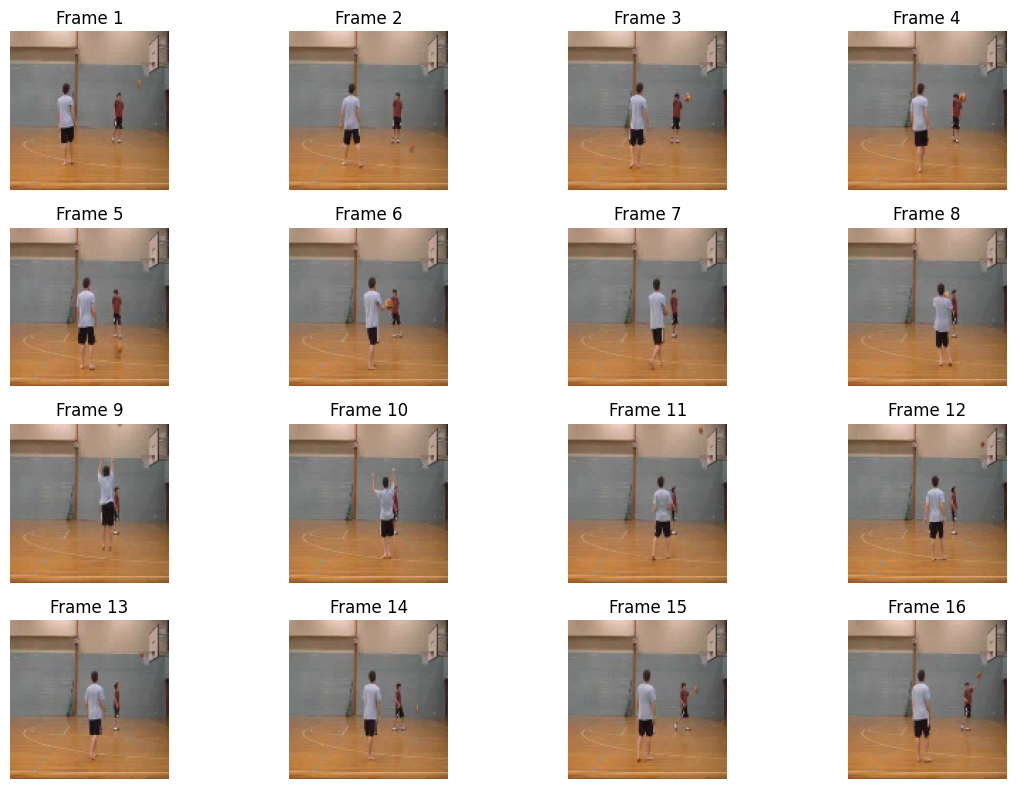

In [ ]:
plt.figure(figsize=(12, 8))

for i in range(len(frames)):
    plt.subplot(4, 4, i + 1)
    plt.imshow(frames[i])
    plt.title(f"Frame {i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
frames = frames.astype("float32") / 255.0

print(frames.shape)
print(frames.min())
print(frames.max())

(16, 112, 112, 3)
0.0
0.94509804


In [ ]:
def extract_frames(video_path, num_frames=16, image_size=(112, 112)):

    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        return None

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames == 0:
        cap.release()
        return None

    frame_indices = np.linspace(
        0,
        total_frames - 1,
        num_frames,
        dtype=int
    )

    frames = []
    last_frame = None

    for index in frame_indices:

        cap.set(cv2.CAP_PROP_POS_FRAMES, index)

        ret, frame = cap.read()

        if ret:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, image_size)
            frame = frame.astype("float32") / 255.0

            frames.append(frame)
            last_frame = frame

        else:
            if last_frame is not None:
                frames.append(last_frame)
            else:
                cap.release()
                return None

    cap.release()

    if len(frames) != num_frames:
        return None

    return np.array(frames)

video_path = "UCF50/Basketball/v_Basketball_g16_c04.avi"
frames = extract_frames(video_path)
print(frames.shape)
print(frames.min())
print(frames.max())

(16, 112, 112, 3)
0.0
1.0


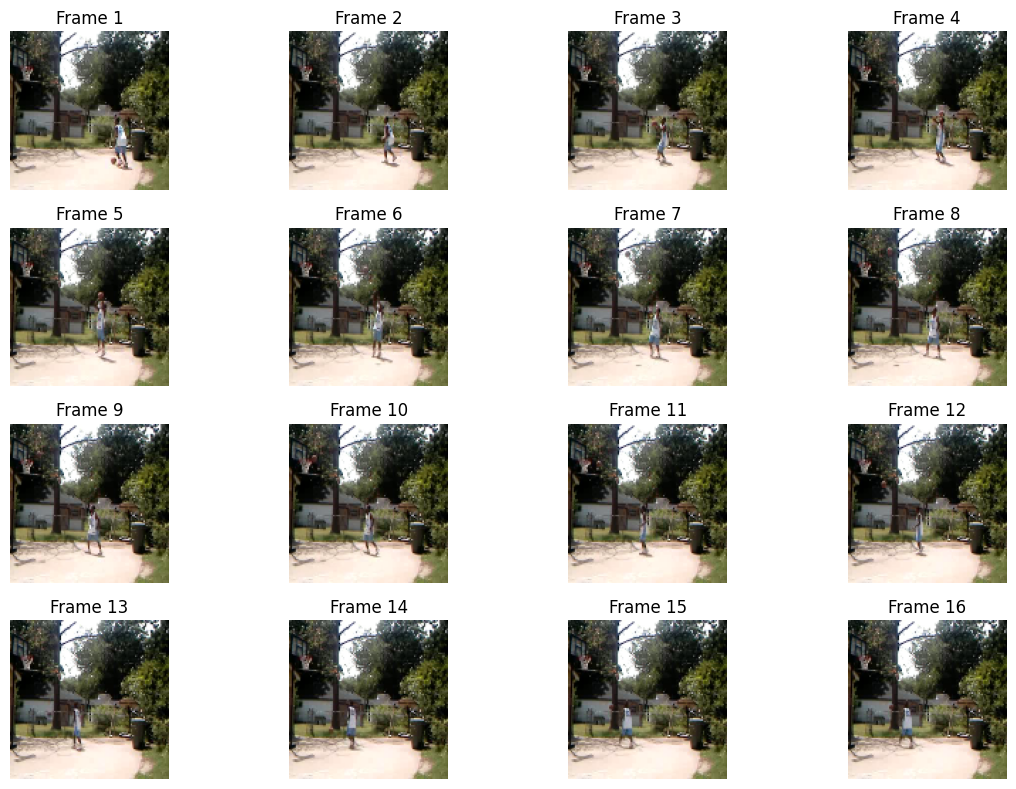

In [ ]:
plt.figure(figsize=(12, 8))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(frames[i])
    plt.title(f"Frame {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
X_train = []
y_train = []

class_labels = {
    "Basketball": 0,
    "Biking": 1,
    "Punch": 2,
    "GolfSwing": 3,
    "HorseRiding": 4
}

for class_name in classes:

    folder = os.path.join("UCF50", class_name)

    class_count = 0

    for video_name in train_data[class_name]:

        video_path = os.path.join(folder, video_name)

        frames = extract_frames(video_path)

        if frames is not None:
            X_train.append(frames)
            y_train.append(class_labels[class_name])
            class_count += 1

    print(class_name, "processed:", class_count)

X_train = np.array(X_train)
y_train = np.array(y_train)

print("\nFinal X_train shape:", X_train.shape)
print("Final y_train shape:", y_train.shape)

Basketball processed: 109
Biking processed: 116
Punch processed: 128
GolfSwing processed: 113


In [ ]:
X_test = []
y_test = []

class_labels = {
    "Basketball": 0,
    "Biking": 1,
    "Punch": 2,
    "GolfSwing": 3,
    "HorseRiding": 4
}

for class_name in classes:

    folder = os.path.join("UCF50", class_name)

    class_count = 0

    for video_name in test_data[class_name]:

        video_path = os.path.join(folder, video_name)

        frames = extract_frames(video_path)

        if frames is not None:
            X_test.append(frames)
            y_test.append(class_labels[class_name])
            class_count += 1

    print(class_name, "processed:", class_count)

X_test = np.array(X_test)
y_test = np.array(y_test)

print("\nFinal X_test shape:", X_test.shape)
print("Final y_test shape:", y_test.shape)

In [ ]:
cnn_base = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(112,112,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2))
])

In [29]:
video_model = models.Sequential([
    layers.Input(shape=(16, 112, 112, 3)),

    layers.TimeDistributed(cnn_base),

    layers.TimeDistributed(
        layers.GlobalAveragePooling2D()
    ),

    layers.LSTM(64),

    layers.Dense(32, activation='relu'),

    layers.Dense(5, activation='softmax')
])

In [30]:
video_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [31]:
video_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_2              │ (None, 16, 26, 26, 64) │        19,392 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 16, 64)         │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,661 (213.52 KB)

 Trainable params: 54,661 (213.52 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
video_model_improved = models.Sequential([
    layers.Input(shape=(16, 112, 112, 3)),

    layers.TimeDistributed(cnn_base),

    layers.TimeDistributed(
        layers.GlobalAveragePooling2D()
    ),

    layers.LSTM(64),

    layers.Dropout(0.3),

    layers.Dense(32, activation='relu'),

    layers.Dropout(0.3),

    layers.Dense(5, activation='softmax')
])

In [33]:
video_model_improved.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [34]:
video_model_improved.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_4              │ (None, 16, 26, 26, 64) │        19,392 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 16, 64)         │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,661 (213.52 KB)

 Trainable params: 54,661 (213.52 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
X_train, y_train = shuffle(
    X_train,
    y_train,
    random_state=42
)

In [36]:
history_improved = video_model_improved.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=8,
    validation_split=0.2,
    shuffle=True
)

Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 77ms/step - accuracy: 0.3735 - loss: 1.4386 - val_accuracy: 0.4000 - val_loss: 1.2624
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.5161 - loss: 1.1810 - val_accuracy: 0.4720 - val_loss: 1.1389
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.5241 - loss: 1.1360 - val_accuracy: 0.4640 - val_loss: 1.1767
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.5462 - loss: 1.1151 - val_accuracy: 0.5200 - val_loss: 1.0702
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - accuracy: 0.5442 - loss: 1.1093 - val_accuracy: 0.5200 - val_loss: 1.0178
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.5703 - loss: 1.0524 - val_accuracy: 0.5600 - val_loss: 0.9691
Epoch 7/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.5863 - loss: 1.0095 - val_accuracy: 0.5840 - val_loss: 1.0264
Epoch 8/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.5502 - loss: 1.0379 - val_accuracy: 0.5360 - v

In [ ]:
print(X_train.shape)
print(y_train.shape)

(623, 16, 112, 112, 3)
(623,)


In [22]:
history = video_model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=8,
    validation_split=0.2
)

Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 81ms/step - accuracy: 0.3313 - loss: 1.5460 - val_accuracy: 0.3360 - val_loss: 1.4818
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.4016 - loss: 1.3185 - val_accuracy: 0.4160 - val_loss: 1.3104
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.4096 - loss: 1.3761 - val_accuracy: 0.3840 - val_loss: 1.3786
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.4056 - loss: 1.4084 - val_accuracy: 0.4160 - val_loss: 1.3773
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.4337 - loss: 1.2863 - val_accuracy: 0.4080 - val_loss: 1.3022
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.4639 - loss: 1.2459 - val_accuracy: 0.4240 - val_loss: 1.2682
Epoch 7/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.4980 - loss: 1.1772 - val_accuracy: 0.4880 - val_loss: 1.1772
Epoch 8/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.5462 - loss: 1.0994 - val_accuracy: 0.4560 - 

In [23]:
test_loss, test_accuracy = video_model.evaluate(
    X_test,
    y_test,
    batch_size=8
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5127 - loss: 1.1025
Test Loss: 1.1025265455245972
Test Accuracy: 0.5126582384109497


In [24]:
y_pred_prob = video_model.predict(X_test, batch_size=8)

y_pred = np.argmax(y_pred_prob, axis=1)

print("Predicted:", y_pred[:20])
print("Actual:   ", y_test[:20])

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step
Predicted: [3 0 4 4 4 0 4 3 1 4 0 2 0 4 1 3 3 1 0 3]
Actual:    [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [25]:
from sklearn.metrics import classification_report

class_names = [
    "Basketball",
    "Biking",
    "Punch",
    "GolfSwing",
    "HorseRiding"
]

print(classification_report(
    y_test,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

  Basketball       0.28      0.25      0.26        28
      Biking       0.22      0.07      0.11        29
       Punch       0.97      0.88      0.92        32
   GolfSwing       0.43      0.83      0.56        29
 HorseRiding       0.51      0.50      0.51        40

    accuracy                           0.51       158
   macro avg       0.48      0.50      0.47       158
weighted avg       0.49      0.51      0.48       158



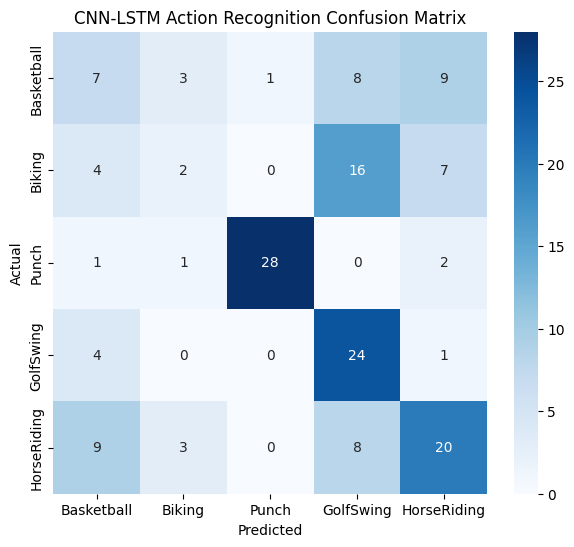

In [26]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN-LSTM Action Recognition Confusion Matrix")
plt.show()

In [37]:
improved_test_loss, improved_test_accuracy = video_model_improved.evaluate(
    X_test,
    y_test,
    batch_size=8
)

print("Improved Test Loss:", improved_test_loss)
print("Improved Test Accuracy:", improved_test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.5759 - loss: 1.0903
Improved Test Loss: 1.0902806520462036
Improved Test Accuracy: 0.5759493708610535


In [38]:
video_model.save("ucf50_cnn_lstm.keras")